# 関係モデルの基礎 Notebook：2人の線形ODE

対応章：[41_love_dynamics_basic.md](../chapters/41_love_dynamics_basic.md)

固有値，時系列，相図を照合し，行列指数関数で実装を検証する．仮想的な無次元状態を扱い，実在人物の感情は推定しない．40の準備を前提に，境界例と過渡応答まで進む．

## ライブラリと係数行列

時間単位を固定する．状態は共通の無次元尺度で表すため，行列の各係数の単位は時間の逆数である．

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

M = np.array([[-0.2, 1.0], [-1.0, -0.2]])
x0 = np.array([1.0, 0.2])
print('M =', M, sep='\n')

Matplotlib is building the font cache; this may take a moment.


M =
[[-0.2  1. ]
 [-1.  -0.2]]


## 参照解と数値積分

$\mathbf{x}(t)=e^{M(t-t_0)}\mathbf{x}(t_0)$ が定数行列の厳密解である．`expm` はこの式を数値評価する．`np.exp(M)` は成分ごとの指数なので代用できない．`t_eval` は出力時刻であり内部刻みではない．`rtol, atol` を変えて誤差を測る．

[SciPy：expm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.expm.html)，[solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

In [2]:
def square_matrix(matrix):
    raw = np.asarray(matrix)
    if np.iscomplexobj(raw):
        raise ValueError('This notebook uses real matrices.')
    matrix = np.asarray(raw, dtype=float)
    if (matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]
            or matrix.shape[0] == 0 or not np.all(np.isfinite(matrix))):
        raise ValueError('matrix must be a nonempty finite square matrix')
    return matrix


def linear_inputs(matrix, x0, times):
    matrix = square_matrix(matrix)
    if np.iscomplexobj(x0) or np.iscomplexobj(times):
        raise ValueError('states and times must be real')
    x0, times = np.asarray(x0, dtype=float), np.asarray(times, dtype=float)
    if x0.shape != (matrix.shape[0],) or not np.all(np.isfinite(x0)):
        raise ValueError('x0 must match the matrix dimension and be finite')
    if (times.ndim != 1 or len(times) < 2 or not np.all(np.isfinite(times))
            or np.any(np.diff(times) <= 0)):
        raise ValueError('times must contain at least two increasing finite values')
    return matrix, x0, times


def solve_linear(matrix, x0, times, rtol=1e-8, atol=1e-10):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    if not (np.isfinite(rtol) and np.isfinite(atol) and rtol > 0 and atol > 0):
        raise ValueError('rtol and atol must be finite and positive')
    sol = solve_ivp(lambda t, x: matrix @ x, (times[0], times[-1]), x0,
                    t_eval=times, rtol=rtol, atol=atol)
    if not sol.success:
        raise RuntimeError(sol.message)
    if sol.y.shape != (len(x0), len(times)) or not np.all(np.isfinite(sol.y)):
        raise RuntimeError('incomplete or nonfinite solution')
    return sol


def linear_reference(matrix, x0, times):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    result = np.column_stack([expm(matrix * (t - times[0])) @ x0 for t in times])
    if not np.all(np.isfinite(result)):
        raise RuntimeError('nonfinite matrix-exponential reference')
    return result

## 数値積分前に固有値から予想する

トレースが負かつ行列式が正なら漸近安定である．判別式が負なら焦点となる．0に近い実部は数式で確認する．

In [3]:
trace = np.trace(M)
determinant = np.linalg.det(M)
eigenvalues = np.linalg.eigvals(M)
discriminant = trace**2 - 4*determinant
print(f'trace={trace:.3f}, determinant={determinant:.3f}, discriminant={discriminant:.3f}')
print('eigenvalues:', eigenvalues)
print('all real parts strictly negative:', np.all(eigenvalues.real < 0))

trace=-0.400, determinant=1.040, discriminant=-4.000
eigenvalues: [-0.2+1.j -0.2-1.j]
all real parts strictly negative: True


## 時系列と参照解を重ねる

基準行列の固有値は $-0.2\pm i$ で，減衰の時定数は5，振動周期は $2\pi$ である．実線が数値解，点が行列指数関数による参照解である．点が重なるだけでなく最大絶対誤差を数値として記録する．

maximum absolute error: 3.0816534324351608e-09


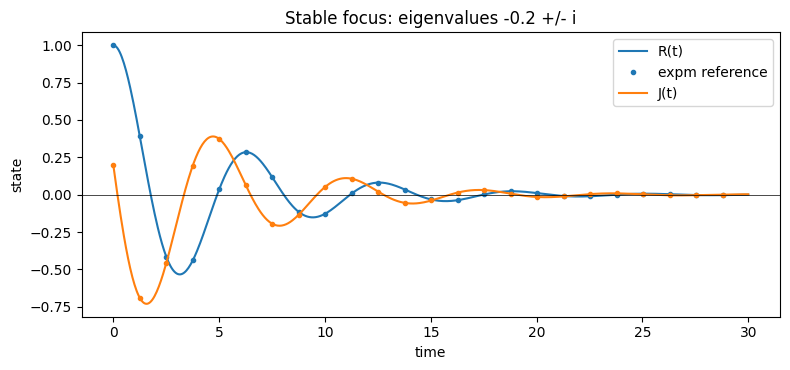

In [4]:
t_eval = np.linspace(0, 30, 600)
solution = solve_linear(M, x0, t_eval)
reference = linear_reference(M, x0, t_eval)
analytic = np.exp(-0.2*t_eval) * np.array([
    x0[0]*np.cos(t_eval) + x0[1]*np.sin(t_eval),
    -x0[0]*np.sin(t_eval) + x0[1]*np.cos(t_eval)])
np.testing.assert_allclose(reference, analytic, atol=1e-13)
print('maximum absolute error:', np.max(np.abs(solution.y - reference)))
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, label in enumerate(['R(t)', 'J(t)']):
    line, = ax.plot(solution.t, solution.y[i], label=label)
    ax.plot(t_eval[::25], reference[i, ::25], '.', color=line.get_color(),
            label='expm reference' if i == 0 else None)
ax.axhline(0, color='black', lw=0.5)
ax.set(xlabel='time', ylabel='state', title='Stable focus: eigenvalues -0.2 +/- i')
ax.legend(); fig.tight_layout(); plt.show()

## ベクトル場と軌道を照合する

黒点は初期値，赤線は同じ数値解を相平面に描いた軌道である．色は状態値ではなく変化率の大きさを表す．矢印をたどると時計回りに原点へ近づく．

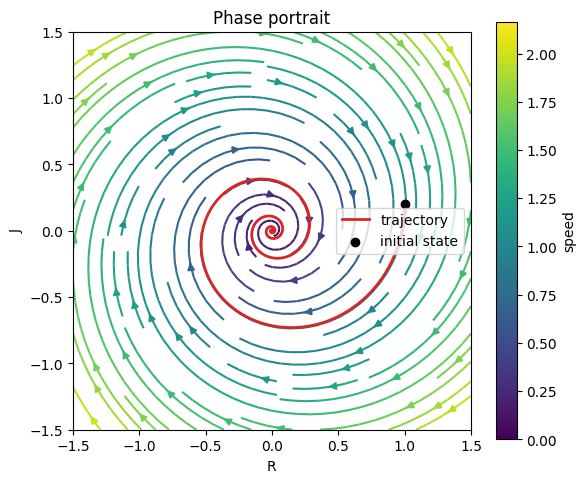

In [5]:
grid = np.linspace(-1.5, 1.5, 17)
R, J = np.meshgrid(grid, grid)
dR = M[0, 0]*R + M[0, 1]*J
dJ = M[1, 0]*R + M[1, 1]*J
speed = np.hypot(dR, dJ)
fig, ax = plt.subplots(figsize=(6, 5))
stream = ax.streamplot(R, J, dR, dJ, color=speed, cmap='viridis', density=1.0)
fig.colorbar(stream.lines, ax=ax, label='speed')
ax.plot(solution.y[0], solution.y[1], color='tab:red', lw=2, label='trajectory')
ax.scatter([x0[0]], [x0[1]], color='black', label='initial state', zorder=3)
ax.set(xlabel='R', ylabel='J', title='Phase portrait')
ax.set_aspect('equal'); ax.legend(); fig.tight_layout(); plt.show()

## 通常の分類と境界例

中心の固有値は $\pm i$ で，ノルムは一定になる．ゼロ固有値が2つの例では $x_1(t)=x_1(0)+tx_2(0)$ なので増大しうる．実部0だけでは安定とは決まらない．また鞍点は不安定だが，安定方向上の初期値からの解は収束する．

In [6]:
cases = {
    'stable node': np.diag([-1.0, -2.0]),
    'saddle': np.diag([1.0, -1.0]),
    'stable focus': np.array([[-0.2, 1.0], [-1.0, -0.2]]),
    'center': np.array([[0.0, 1.0], [-1.0, 0.0]]),
    'zero-eigenvalue shear': np.array([[0.0, 1.0], [0.0, 0.0]]),
}
for name, matrix in cases.items():
    print(f'{name:22s}: eigenvalues={np.linalg.eigvals(matrix)}')

stable node           : eigenvalues=[-1. -2.]
saddle                : eigenvalues=[ 1. -1.]
stable focus          : eigenvalues=[-0.2+1.j -0.2-1.j]
center                : eigenvalues=[0.+1.j 0.-1.j]
zero-eigenvalue shear : eigenvalues=[0. 0.]


## 許容誤差を変えた検証

下の例では同じ出力時刻で積分許容誤差だけを変える．誤差は参照解との差を全成分・全保存時刻で測った最大値である．局所誤差制御が全体誤差の上限を保証するわけではなく，極小の許容値では丸め誤差の限界もある．

In [7]:
rows = []
for rtol in [1e-3, 1e-6, 1e-9]:
    sol = solve_linear(M, x0, t_eval, rtol=rtol, atol=rtol/100)
    rows.append({'rtol': rtol, 'atol': rtol/100, 'nfev': sol.nfev,
                 'max_abs_error': np.max(np.abs(sol.y - reference))})
accuracy = pd.DataFrame(rows)
print(accuracy.to_string(index=False))
assert accuracy.iloc[-1].max_abs_error < accuracy.iloc[0].max_abs_error

        rtol         atol  nfev  max_abs_error
1.000000e-03 1.000000e-05   218   4.656387e-04
1.000000e-06 1.000000e-08   764   3.393521e-07
1.000000e-09 1.000000e-11  2984   3.025597e-10


## 安定でも途中で増幅する例

$M=\begin{pmatrix}-1&K\\0&-1\end{pmatrix}$ は $K$ によらず固有値が $-1,-1$ である．初期値 $(0,1)^\top$ の解は $e^{-t}(Kt,1)^\top$ となる．左図で厳密解との一致，右図で $K=6$ の一時的なノルム増大と最終的な減衰を確認する．これは数値的不安定性ではない．

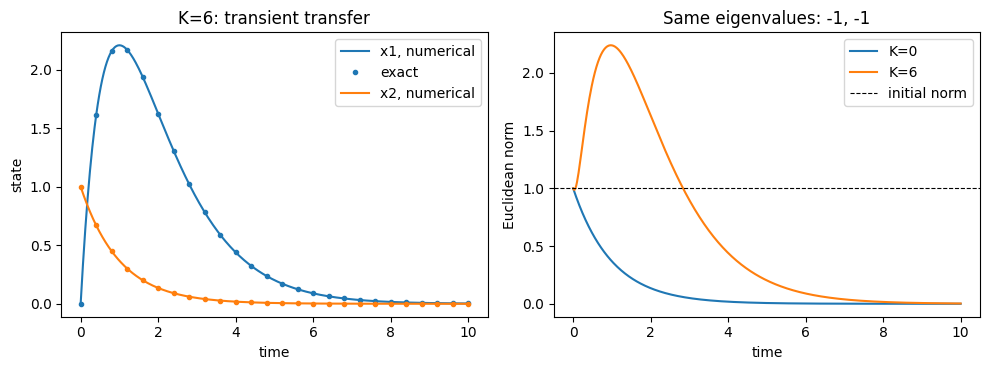

In [8]:
times = np.linspace(0, 10, 501)
initial = np.array([0.0, 1.0])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for K in [0.0, 6.0]:
    matrix = np.array([[-1.0, K], [0.0, -1.0]])
    sol = solve_linear(matrix, initial, times)
    exact = np.exp(-times)*np.array([K*times, np.ones_like(times)])
    np.testing.assert_allclose(sol.y, exact, atol=2e-8, rtol=1e-7)
    axes[1].plot(times, np.linalg.norm(sol.y, axis=0), label=f'K={K:g}')
    if K == 6:
        for i in range(2):
            line, = axes[0].plot(times, sol.y[i], label=f'x{i+1}, numerical')
            axes[0].plot(times[::20], exact[i, ::20], '.', color=line.get_color(),
                         label='exact' if i == 0 else None)
axes[0].set(xlabel='time', ylabel='state', title='K=6: transient transfer')
axes[1].axhline(1, color='black', ls='--', lw=0.8, label='initial norm')
axes[1].set(xlabel='time', ylabel='Euclidean norm', title='Same eigenvalues: -1, -1')
for ax in axes:
    ax.legend()
fig.tight_layout(); plt.show()

## 課題

実装後は関数の返り値と `assert` を使い，既知の解で検証する．数値の許容幅による判定と数学的な境界の判定は区別する．

1. `classify_linear_system(M)` を作り，トレース，行列式，固有値，最大実部，分類を辞書で返す．安定節点，鞍点，安定焦点を確認する．実部が0付近なら境界付近と返し，中心とゼロ固有値の例を手計算で区別する．
2. `simulate_linear_system(M, x0, t_end, rtol, atol)` を作り，時刻と2成分をDataFrameで返す．積分の成否，有限値，入力形状を確認し，行列指数関数との最大絶対誤差を求める．
3. 鞍点 $M=\operatorname{diag}(1,-1)$ を，初期値 $(0,1)^\top$ と $(10^{-3},1)^\top$ で比較するコードを書け．同じ不安定な系に収束する軌道があることを図と数値で確かめよ．
4. `accuracy_table(M, x0, times, rtols)` を作り，`atol=rtol/100` として参照解との最大絶対誤差と関数評価回数を表にする．基準の焦点で許容誤差を小さくした場合を比較する．`t_eval` の点数を増やすこととの違いも記す．
5. `transient_gain(M, x0, times)` を作り，保存時刻での最大ノルムを初期ノルムで割った値と，その時刻を返す．$M=\begin{pmatrix}-1&K\\0&-1\end{pmatrix}$，$\mathbf{x}(0)=(0,1)^\top$ で $K=0,2,6$ を比較する．この最大値は連続時間の真の最大値を下から近似するので，保存時刻を細かくした場合も確認する．

In [9]:
# 課題実装セル
# 分類，数値解，鞍点の初期値比較，誤差表，一時的増幅の関数を実装する．